# 17 Transit Capital Investment Program

## Purpose

This notebook turns the corridor investment rankings from Notebook 16 into a hypothetical capital investment program.

Notebook 16 answered:

> Which corridors should receive priority for future transit investment?

This notebook asks:

> If Houston had a dedicated transit improvement budget, how could that money be allocated across priority corridors?

## Research Question

How could a hypothetical transit capital budget be distributed across Houston METRO corridors based on investment priority, recommended investment type, and corridor need?

## Scenario

This notebook creates a hypothetical:

**Houston Transit Improvement Program**  
**Total Budget: $500 million**

The budget is allocated across three investment categories:

- Rail / BRT Candidate corridors
- BRT Candidate corridors
- Enhanced Bus Service corridors

This is a planning scenario, not an official METRO budget.


## 1. Introduction

Previous notebooks created the data foundation for corridor investment planning:

- Notebook 13 measured route productivity.
- Notebook 15 built a Transit Accessibility Index.
- Notebook 16 ranked corridors by investment priority.

This notebook converts those rankings into a hypothetical funding program. This helps make the project more useful for a future website because users can understand not only which corridors rank highly, but also what a plausible funding strategy might look like.


## 2. Load ROI Results

The capital investment scenario uses the final output from Notebook 16:

`data/processed/transit_investment_roi_analysis.csv`

This file should include:

- `route_name`
- `investment_priority`
- `investment_tier`
- `recommended_investment`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

investment = pd.read_csv(
    "../data/processed/transit_investment_roi_analysis.csv"
)

# Recreate tier and recommendation columns if the CSV was saved before those fields existed.
if "investment_tier" not in investment.columns:
    investment["investment_tier"] = pd.cut(
        investment["investment_priority"],
        bins=[0, 0.35, 0.50, 0.65, 1],
        labels=[
            "Low Priority",
            "Moderate Priority",
            "High Priority",
            "Flagship Corridor"
        ]
    )

if "recommended_investment" not in investment.columns:

    def recommend_investment(score):

        if score >= 0.55:
            return "Rail / BRT Candidate"

        elif score >= 0.45:
            return "BRT Candidate"

        else:
            return "Enhanced Bus Service"

    investment["recommended_investment"] = (
        investment["investment_priority"]
        .apply(recommend_investment)
    )

print(investment.shape)

investment.head()

(90, 9)


,route_name,investment_priority,demand_score,route_equity_score,route_accessibility_score,rail_gap_score,population_served,investment_tier,recommended_investment
0,Harwin Express,0.619929,0.276167,0.180608,0.032918,13009.767023,3548012.0,High Priority,Rail / BRT Candidate
1,Westheimer,0.601180,0.776263,0.169695,0.047239,11465.913102,1088928.0,High Priority,Rail / BRT Candidate
2,Fondren,0.585410,0.671342,0.167254,0.000000,12460.784805,553884.0,High Priority,Rail / BRT Candidate
3,Gessner,0.584972,0.669133,0.123084,0.000000,16261.835335,792716.0,High Priority,Rail / BRT Candidate
4,Hillcroft,0.555218,0.390269,0.204404,0.000000,10613.475510,1180520.0,High Priority,Rail / BRT Candidate


## 3. Review Corridor Rankings

Before creating a budget scenario, the notebook reviews the highest-priority corridors from the investment model.

These rankings come from the combined score created in Notebook 16, which considered:

- Demand
- Productivity
- Equity context
- Accessibility need
- Rail gap
- Population exposure


In [2]:
top_corridors = (
    investment
    .sort_values(
        "investment_priority",
        ascending=False
    )
    .copy()
)

top_corridors[
    [
        "route_name",
        "investment_priority",
        "investment_tier",
        "recommended_investment"
    ]
].head(25)

,route_name,investment_priority,investment_tier,recommended_investment
0,Harwin Express,0.619929,High Priority,Rail / BRT Candidate
1,Westheimer,0.601180,High Priority,Rail / BRT Candidate
2,Fondren,0.585410,High Priority,Rail / BRT Candidate
3,Gessner,0.584972,High Priority,Rail / BRT Candidate
4,Hillcroft,0.555218,High Priority,Rail / BRT Candidate
5,Bellaire,0.539828,High Priority,BRT Candidate
6,Richmond,0.510331,High Priority,BRT Candidate
7,Bissonnet,0.497552,Moderate Priority,BRT Candidate
8,Harwin Express,0.494793,Moderate Priority,BRT Candidate
9,Beechnut,0.494773,Moderate Priority,BRT Candidate


## 4. Create Investment Tiers

The final recommendations are grouped into three broad investment categories.

These categories are intentionally simple and are meant to support a planning-screening exercise:

| Recommended Investment | Meaning |
|---|---|
| Rail / BRT Candidate | Strongest corridors for high-capacity transit study |
| BRT Candidate | Corridors suitable for more intensive bus priority or BRT-style improvements |
| Enhanced Bus Service | Corridors better suited for frequency, reliability, stop, and operational improvements |

Duplicate route names may appear because GTFS and route geometry can represent similar services with different route records. For a future production website, these could be manually consolidated into broader named corridors.


In [3]:
investment_category_summary = (
    top_corridors
    .groupby("recommended_investment")
    .agg(
        corridor_count=("route_name", "count"),
        total_priority=("investment_priority", "sum"),
        average_priority=("investment_priority", "mean")
    )
    .reset_index()
    .sort_values(
        "average_priority",
        ascending=False
    )
)

investment_category_summary

,recommended_investment,corridor_count,total_priority,average_priority
2,Rail / BRT Candidate,5,2.946709,0.589342
0,BRT Candidate,11,5.332528,0.484775
1,Enhanced Bus Service,74,20.328297,0.282337


## 5. Define Budget Scenario

This notebook uses a hypothetical total budget of:

# $500 million

The budget is divided across investment categories using a tiered strategy:

| Category | Share of Budget |
|---|---:|
| Rail / BRT Candidate | 60% |
| BRT Candidate | 30% |
| Enhanced Bus Service | 10% |

This reflects the idea that high-capacity transit corridors require larger capital investments, while enhanced bus corridors can often be improved with smaller amounts of funding.


In [4]:
total_budget = 500_000_000

budget_shares = {
    "Rail / BRT Candidate": 0.60,
    "BRT Candidate": 0.30,
    "Enhanced Bus Service": 0.10
}

budget_by_category = pd.DataFrame(
    [
        {
            "recommended_investment": category,
            "budget_share": share,
            "category_budget": total_budget * share
        }
        for category, share in budget_shares.items()
    ]
)

budget_by_category

,recommended_investment,budget_share,category_budget
0,Rail / BRT Candidate,0.6,300000000.0
1,BRT Candidate,0.3,150000000.0
2,Enhanced Bus Service,0.1,50000000.0


## 6. Allocate Funds

Within each investment category, funds are allocated proportionally based on each corridor's investment priority score.

This means a corridor with a higher priority score receives a larger share of its category's budget.

Formula:

`Corridor Allocation = Category Budget × (Corridor Priority / Total Priority Within Category)`


In [5]:
budget_allocation = top_corridors.merge(
    budget_by_category,
    on="recommended_investment",
    how="left"
)

category_priority_totals = (
    budget_allocation
    .groupby("recommended_investment")["investment_priority"]
    .transform("sum")
)

budget_allocation["allocation_share_within_category"] = (
    budget_allocation["investment_priority"]
    /
    category_priority_totals
)

budget_allocation["allocated_budget"] = (
    budget_allocation["category_budget"]
    *
    budget_allocation["allocation_share_within_category"]
)

budget_allocation["allocated_budget_millions"] = (
    budget_allocation["allocated_budget"] / 1_000_000
)

budget_allocation[
    [
        "route_name",
        "recommended_investment",
        "investment_priority",
        "allocated_budget_millions"
    ]
].sort_values(
    "allocated_budget_millions",
    ascending=False
).head(25)

,route_name,recommended_investment,investment_priority,allocated_budget_millions
0,Harwin Express,Rail / BRT Candidate,0.619929,63.114020
1,Westheimer,Rail / BRT Candidate,0.601180,61.205210
2,Fondren,Rail / BRT Candidate,0.585410,59.599714
3,Gessner,Rail / BRT Candidate,0.584972,59.555146
4,Hillcroft,Rail / BRT Candidate,0.555218,56.525909
5,Bellaire,BRT Candidate,0.539828,15.184948
6,Richmond,BRT Candidate,0.510331,14.355240
7,Bissonnet,BRT Candidate,0.497552,13.995756
8,Harwin Express,BRT Candidate,0.494793,13.918150
9,Beechnut,BRT Candidate,0.494773,13.917597


## 7. Corridor Recommendations

This section translates funding levels into planning recommendations.

The recommendations are screening-level suggestions. They are not official cost estimates or engineering plans.


In [6]:
def describe_program(row):

    if row["recommended_investment"] == "Rail / BRT Candidate":
        return (
            "Fund corridor planning, high-capacity transit study, "
            "BRT design alternatives, and possible rail feasibility work."
        )

    elif row["recommended_investment"] == "BRT Candidate":
        return (
            "Fund BRT-style improvements such as bus priority, stations, "
            "higher frequency, signal priority, and corridor reliability upgrades."
        )

    else:
        return (
            "Fund enhanced bus improvements such as more frequent service, "
            "stop upgrades, reliability improvements, and better transfers."
        )


budget_allocation["program_recommendation"] = (
    budget_allocation.apply(
        describe_program,
        axis=1
    )
)

budget_allocation[
    [
        "route_name",
        "recommended_investment",
        "allocated_budget_millions",
        "program_recommendation"
    ]
].sort_values(
    "allocated_budget_millions",
    ascending=False
).head(20)

,route_name,recommended_investment,allocated_budget_millions,program_recommendation
0,Harwin Express,Rail / BRT Candidate,63.114020,"Fund corridor planning, high-capacity transit ..."
1,Westheimer,Rail / BRT Candidate,61.205210,"Fund corridor planning, high-capacity transit ..."
2,Fondren,Rail / BRT Candidate,59.599714,"Fund corridor planning, high-capacity transit ..."
3,Gessner,Rail / BRT Candidate,59.555146,"Fund corridor planning, high-capacity transit ..."
4,Hillcroft,Rail / BRT Candidate,56.525909,"Fund corridor planning, high-capacity transit ..."
5,Bellaire,BRT Candidate,15.184948,Fund BRT-style improvements such as bus priori...
6,Richmond,BRT Candidate,14.355240,Fund BRT-style improvements such as bus priori...
7,Bissonnet,BRT Candidate,13.995756,Fund BRT-style improvements such as bus priori...
8,Harwin Express,BRT Candidate,13.918150,Fund BRT-style improvements such as bus priori...
9,Beechnut,BRT Candidate,13.917597,Fund BRT-style improvements such as bus priori...


## 8. Investment Portfolio Summary

This section summarizes the hypothetical $500 million investment program by category.

This view is useful for a future website because it shows how the total budget is split across major investment strategies.


In [7]:
portfolio_summary = (
    budget_allocation
    .groupby("recommended_investment")
    .agg(
        corridor_count=("route_name", "count"),
        total_allocated_budget=("allocated_budget", "sum"),
        average_allocation=("allocated_budget", "mean")
    )
    .reset_index()
)

portfolio_summary["total_allocated_budget_millions"] = (
    portfolio_summary["total_allocated_budget"] / 1_000_000
)

portfolio_summary["average_allocation_millions"] = (
    portfolio_summary["average_allocation"] / 1_000_000
)

portfolio_summary[
    [
        "recommended_investment",
        "corridor_count",
        "total_allocated_budget_millions",
        "average_allocation_millions"
    ]
]

,recommended_investment,corridor_count,total_allocated_budget_millions,average_allocation_millions
0,BRT Candidate,11,150.0,13.636364
1,Enhanced Bus Service,74,50.0,0.694444
2,Rail / BRT Candidate,5,300.0,60.000000


## 9. Visualizations

The following charts summarize the hypothetical capital investment program.

These charts can later be adapted into website visuals.


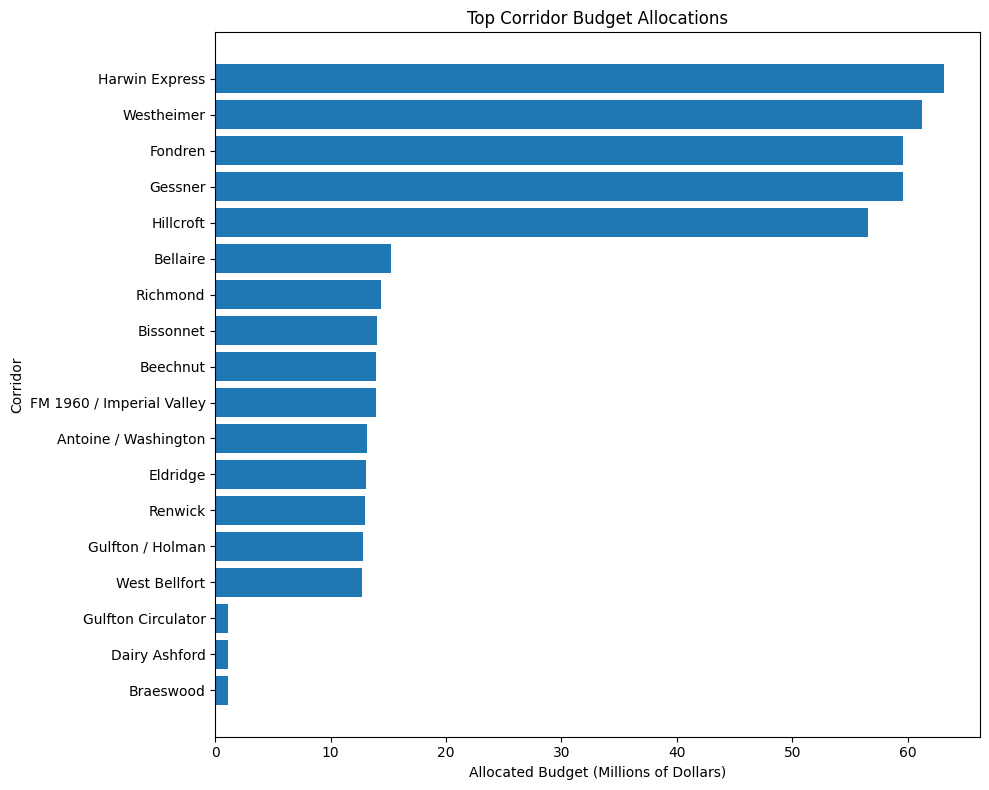

In [8]:
top20_budget = (
    budget_allocation
    .sort_values(
        "allocated_budget",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_budget["route_name"],
    top20_budget["allocated_budget_millions"]
)

plt.gca().invert_yaxis()

plt.title("Top Corridor Budget Allocations")
plt.xlabel("Allocated Budget (Millions of Dollars)")
plt.ylabel("Corridor")

plt.tight_layout()
plt.show()

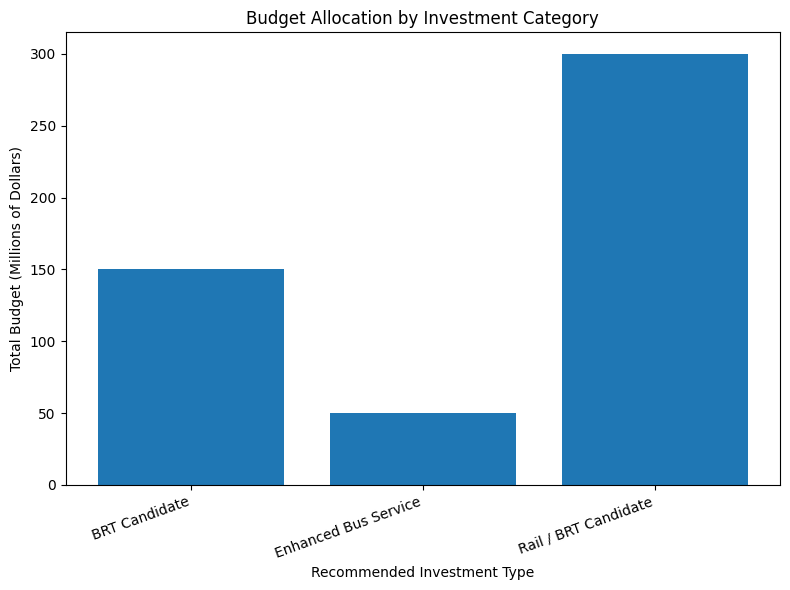

In [9]:
plt.figure(figsize=(8, 6))

plt.bar(
    portfolio_summary["recommended_investment"],
    portfolio_summary["total_allocated_budget_millions"]
)

plt.title("Budget Allocation by Investment Category")
plt.xlabel("Recommended Investment Type")
plt.ylabel("Total Budget (Millions of Dollars)")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

## 10. Conclusions

This notebook creates a hypothetical $500 million Houston Transit Improvement Program using the corridor investment scores from Notebook 16.

The scenario demonstrates how analytical scores can be translated into a funding strategy:

- The largest share of funding is directed toward Rail / BRT Candidate corridors.
- A second funding pool supports BRT Candidate corridors.
- A smaller but important share supports Enhanced Bus Service corridors.

This type of budget scenario is useful for the final website because it turns abstract priority scores into a more understandable planning question:

> If Houston had $500 million to invest in transit, where might the money go?

## Important Caveat

The dollar amounts in this notebook are hypothetical and should not be interpreted as actual project cost estimates. Real capital planning would require:

- Detailed engineering studies
- Right-of-way analysis
- Environmental review
- Operating cost estimates
- Public engagement
- Funding and governance review

However, the framework provides a clear and transparent way to connect corridor priority scores with a realistic investment planning scenario.


## Save Capital Investment Program Output

The final budget allocation table is saved for use in the final written report and future website development.


In [10]:
budget_allocation.to_csv(
    "../data/processed/transit_capital_investment_program.csv",
    index=False
)

print("saved")

saved
